In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#defining the parameters
h_values = np.arange(0.01, 1.01, 0.05)
x_start, x_end = 0, 2

In [3]:
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

In [4]:
all_results = []

In [5]:
#doing euler for different step sizes
for h in h_values:
    num_steps = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = 1
    for i in range(num_steps):
        y[i+1] = y[i] + h * f(x[i], y[i])

    all_results.append((h, x, y))

ref_h, ref_x, ref_y = all_results[0]


In [6]:
# reference
ref_h, ref_x, ref_y = all_results[0]

Step size h = 0.01
current vs first error: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.0
Step size h = 0.060000000000000005
current vs first error: [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0.01021165 0.00951235 0.00883622 0.00818748 0.00756906

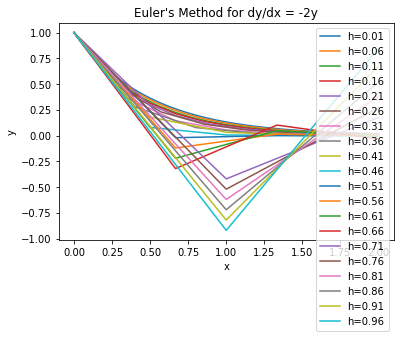

In [7]:
for h, x, y in all_results:
    plt.plot(x, y, label="h=" + str(round(h, 2)))

    # Compare with the reference
    aligned_ref_y = np.interp(x, ref_x, ref_y)
    error = np.abs(aligned_ref_y - y)
    total_error = np.sum(error)

    print("Step size h =", h)
    print("current vs first error:", error)
    print("Total accumulated error:", total_error)
    
    
plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y")
plt.legend()
plt.show()


In [32]:
#setting up the error funcs
def exact(x):
    return np.exp(-2 * x)

def glob_err(x, y_euler):
    return np.abs(exact(x) - y_euler)

def loc_err(x, h):
    exact_prev = exact(x - h)
    exact_current = exact(x)
    euler_step = exact_prev + h * f(x - h, exact_prev)
    return np.abs(exact_current - euler_step)

h_2 = [0.1, 0.5, 1.0, 1.5]

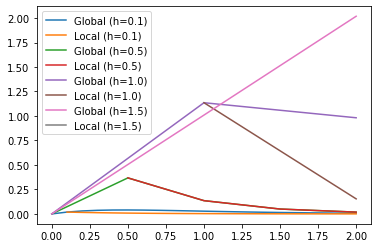

In [36]:
for h in h_2:
    num_steps = int(2 / h) 
    x_l = np.linspace(0, 2, num_steps + 1)
    
    # getting the euler y values
    y_euler = np.zeros(num_steps + 1)
    y_euler[0] = 1
    for i in range(num_steps):
        y_euler[i+1] = y_euler[i] + h * f(x_l[i], y_euler[i])
        
    #using the functions to find the error 
    global_err = glob_err(x_l, y_euler)
    local_err = [loc_err(x, h) for x in x_l[1:]]
    
    plt.plot(x_l, global_err, label=f'Global (h={h})')
    plt.plot(x_l[1:], local_err, label=f'Local (h={h})')
    plt.legend()